In [35]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Real and Fake Audio Analysis

### Load Both Audios

In [36]:
audio_path = "fake.mp3"

REAL_FILE = "real.wav"
FAKE_FILE = "fake.mp3"

real, sr_real = librosa.load(REAL_FILE, sr=16000)
fake, sr_fake = librosa.load(FAKE_FILE, sr=16000)

print("-----------Real-----------")
print(real.shape)
print("-----------Fake-----------")
print(fake.shape)

-----------Real-----------
(120576,)
-----------Fake-----------
(116352,)


Note: Illegal Audio-MPEG-Header 0x332c3230 at offset 290880.
Note: Trying to resync...
Note: Hit end of (available) data during resync.


### Waveform Comparison

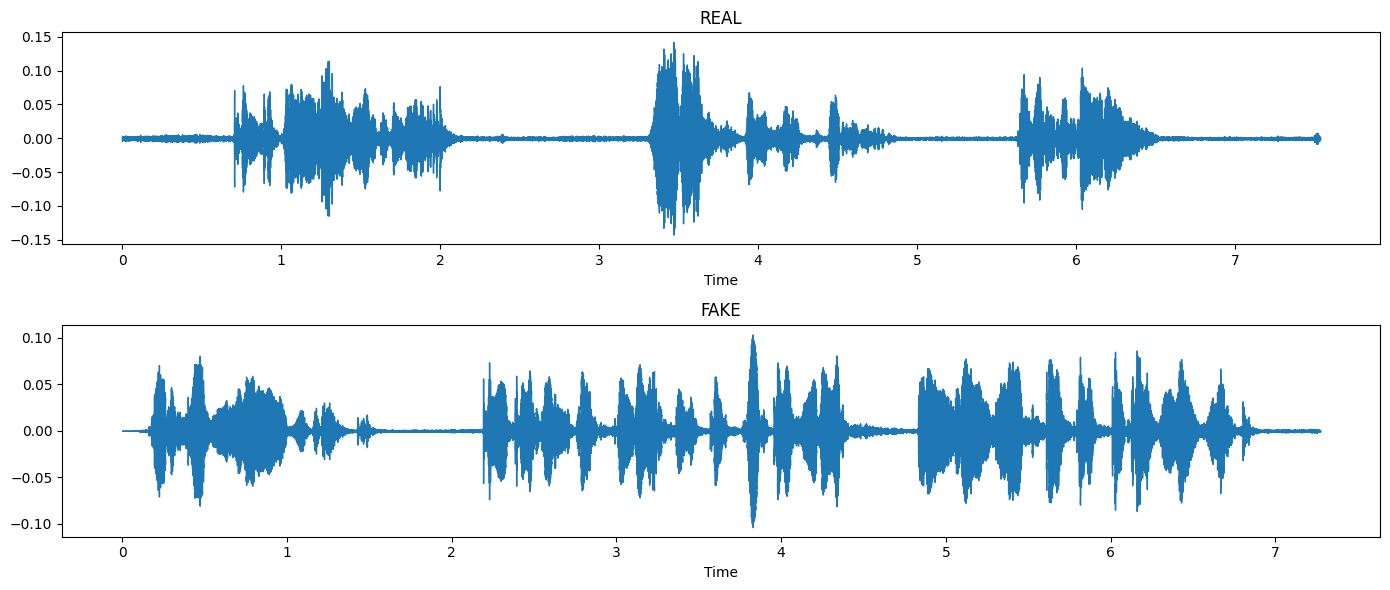

In [37]:
fig, ax = plt.subplots(2, 1, figsize=(14,6))

librosa.display.waveshow(real, sr=16000, ax=ax[0])
ax[0].set_title("REAL")

librosa.display.waveshow(fake, sr=16000, ax=ax[1])
ax[1].set_title("FAKE")

plt.tight_layout()
plt.show()

### Spectrogram Comparison

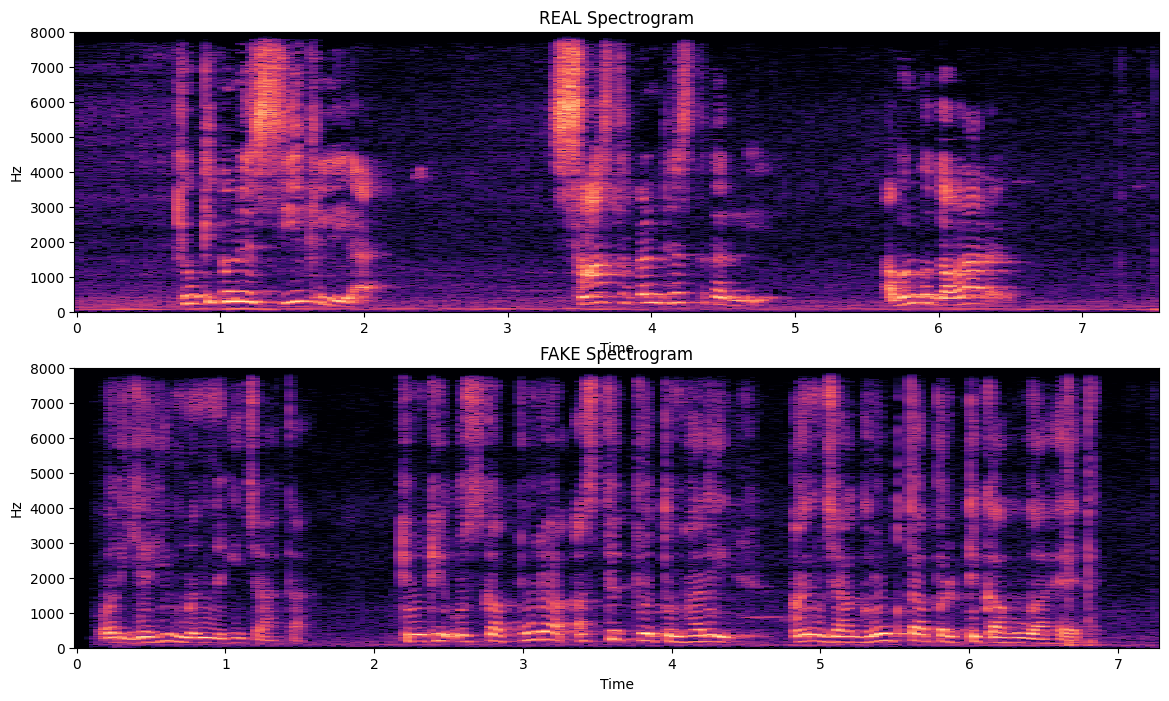

In [38]:
real_stft = librosa.stft(real)
fake_stft = librosa.stft(fake)

real_db = librosa.amplitude_to_db(
    np.abs(real_stft),
    ref=np.max
)

fake_db = librosa.amplitude_to_db(
    np.abs(fake_stft),
    ref=np.max
)

fig, ax = plt.subplots(2,1,figsize=(14,8))

librosa.display.specshow(
    real_db,
    sr=16000,
    x_axis='time',
    y_axis='hz',
    ax=ax[0]
)

ax[0].set_title("REAL Spectrogram")

librosa.display.specshow(
    fake_db,
    sr=16000,
    x_axis='time',
    y_axis='hz',
    ax=ax[1]
)

ax[1].set_title("FAKE Spectrogram")

plt.show()

### Pitch Comparison

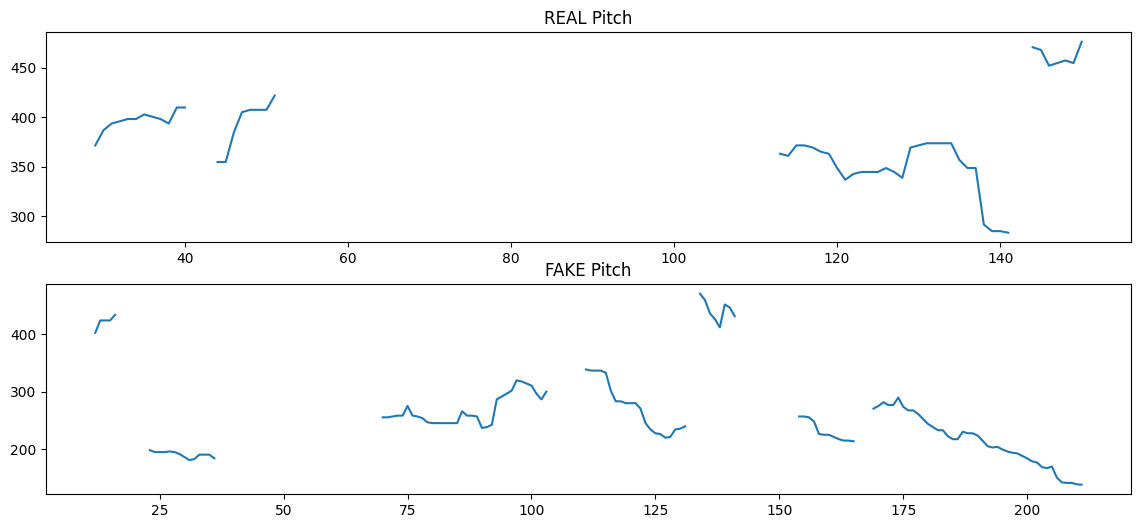

In [39]:
real_f0, _, _ = librosa.pyin(
    real,
    fmin=75,
    fmax=500
)

fake_f0, _, _ = librosa.pyin(
    fake,
    fmin=75,
    fmax=500
)

fig, ax = plt.subplots(2,1,figsize=(14,6))

ax[0].plot(real_f0)
ax[0].set_title("REAL Pitch")

ax[1].plot(fake_f0)
ax[1].set_title("FAKE Pitch")

plt.show()

### MFCC Comparison

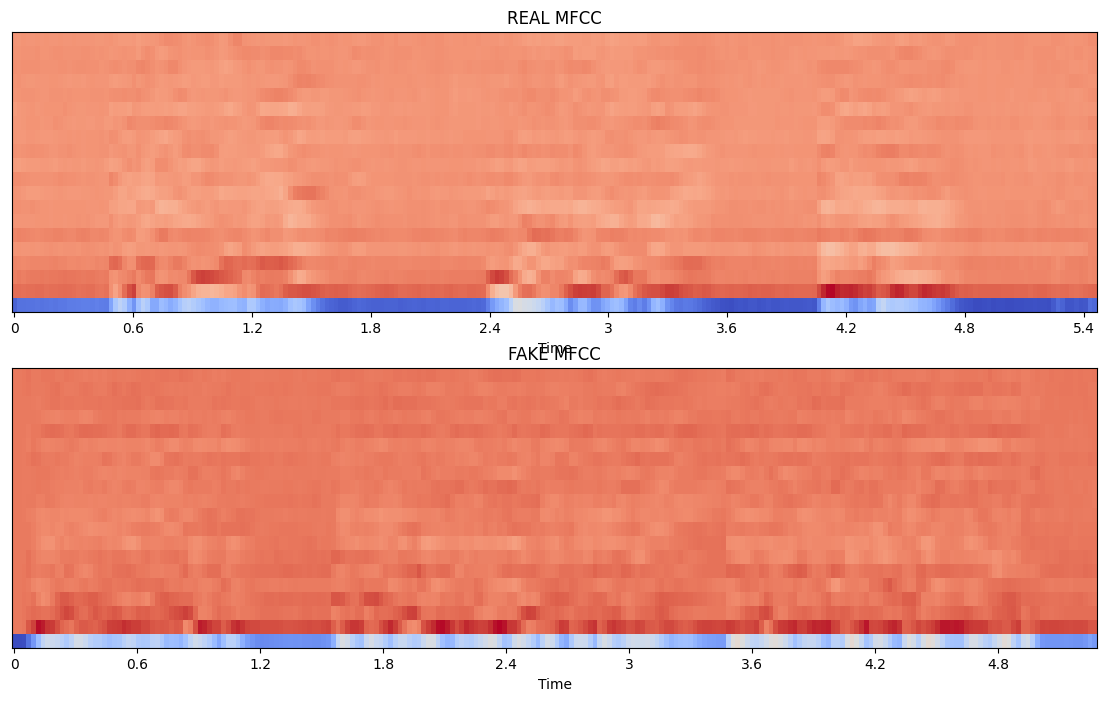

In [40]:
real_mfcc = librosa.feature.mfcc(
    y=real,
    sr=16000,
    n_mfcc=20
)

fake_mfcc = librosa.feature.mfcc(
    y=fake,
    sr=16000,
    n_mfcc=20
)

fig, ax = plt.subplots(2,1,figsize=(14,8))

librosa.display.specshow(
    real_mfcc,
    x_axis='time',
    ax=ax[0]
)

ax[0].set_title("REAL MFCC")

librosa.display.specshow(
    fake_mfcc,
    x_axis='time',
    ax=ax[1]
)

ax[1].set_title("FAKE MFCC")

plt.show()

### Delta MFCC Comparison

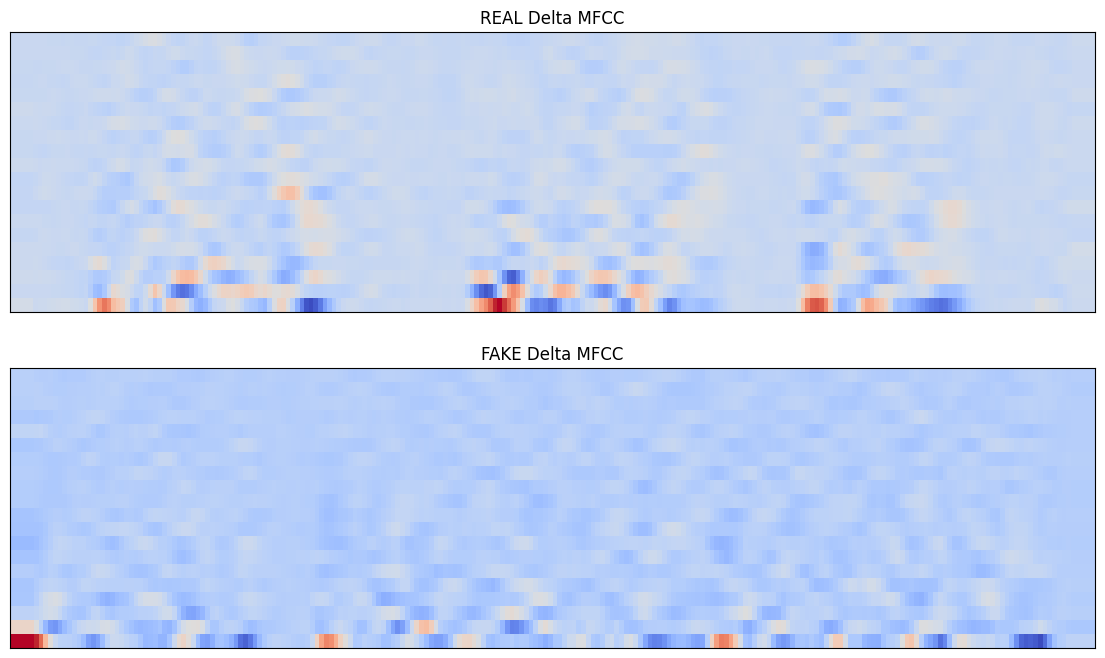

In [41]:
real_delta = librosa.feature.delta(real_mfcc)
fake_delta = librosa.feature.delta(fake_mfcc)

fig, ax = plt.subplots(2,1,figsize=(14,8))

librosa.display.specshow(real_delta, ax=ax[0])
ax[0].set_title("REAL Delta MFCC")

librosa.display.specshow(fake_delta, ax=ax[1])
ax[1].set_title("FAKE Delta MFCC")

plt.show()

### Statistical Features

In [42]:
def extract_stats(audio):

    centroid = librosa.feature.spectral_centroid(
        y=audio,
        sr=16000
    )[0]

    flatness = librosa.feature.spectral_flatness(
        y=audio
    )[0]

    zcr = librosa.feature.zero_crossing_rate(
        audio
    )[0]

    rms = librosa.feature.rms(
        y=audio
    )[0]

    return {
        "centroid_mean": np.mean(centroid),
        "centroid_std": np.std(centroid),

        "flatness_mean": np.mean(flatness),
        "flatness_std": np.std(flatness),

        "zcr_mean": np.mean(zcr),
        "zcr_std": np.std(zcr),

        "rms_mean": np.mean(rms),
        "rms_std": np.std(rms),
    }

real_stats = extract_stats(real)
fake_stats = extract_stats(fake)

comparison = pd.DataFrame(
    {
        "REAL": real_stats,
        "FAKE": fake_stats
    }
)

comparison

,REAL,FAKE
centroid_mean,2166.590237,1900.208138
centroid_std,1033.182312,864.337690
flatness_mean,0.023579,0.032375
flatness_std,0.021602,0.097331
zcr_mean,0.149588,0.116040
zcr_std,0.131026,0.090618
rms_mean,0.009703,0.014067
rms_std,0.010352,0.009871


### MFCC Statistics

In [43]:
mfcc_features = {}

for i in range(20):

    mfcc_features[f"mfcc_{i+1}_mean"] = [
        np.mean(real_mfcc[i]),
        np.mean(fake_mfcc[i])
    ]

    mfcc_features[f"mfcc_{i+1}_std"] = [
        np.std(real_mfcc[i]),
        np.std(fake_mfcc[i])
    ]

mfcc_df = pd.DataFrame(
    mfcc_features,
    index=["REAL","FAKE"]
)

mfcc_df.T

,REAL,FAKE
mfcc_1_mean,-445.660156,-417.480804
mfcc_1_std,94.610001,96.258835
mfcc_2_mean,69.155365,78.139633
mfcc_2_std,48.959587,36.904945
mfcc_3_mean,27.934273,23.838709
mfcc_3_std,32.306889,23.481707
mfcc_4_mean,22.691359,11.299113
mfcc_4_std,24.953726,22.874289
mfcc_5_mean,-10.198901,-3.966648
mfcc_5_std,21.114042,16.179268
